In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import pickle
from IPython.display import Image, display

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1788506058.663638    1056 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788506058.980233    1056 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788506060.810217    1056 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# Get the GPUs available.
tf.config.list_physical_devices("GPU")

E0000 00:00:1788506063.236157    1056 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


[]

In [4]:
IMAGE_SIZE = (224, 224)
COLOR_MODE = "rgb"

## Test

In [5]:
model = tf.keras.models.load_model("../classification/model.keras")
labels = ['human',
 'vehicle',
 'bird',
 'cow',
 'fox',
 'hare',
 'dog',
 'cat',
 'None_of_the_above',
 'weasel',
 'bear',
 'deer',
 'badger',
 'squirrel',
 'wolf',
 'boar']

In [6]:
# Define path to an image to test.
path_image_test = "/mnt/c/Users/pietr/Desktop/image.jpg"

In [7]:
img = keras.preprocessing.image.load_img(path_image_test, target_size=IMAGE_SIZE, color_mode=COLOR_MODE, interpolation="bilinear")
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  

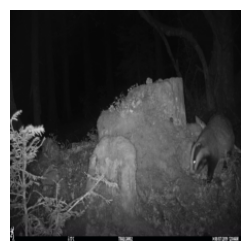

In [8]:
plt.figure(figsize = (3, 3))
plt.imshow(img_array.numpy().squeeze().astype("uint8"))
plt.axis("off");

In [9]:
predictions = model.predict(img_array)

I0000 00:00:1788506074.036724    1167 service.cc:153] XLA service 0x769924071c50 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788506074.036753    1167 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1788506074.142140    1167 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788506074.985527    1167 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [10]:
np.round(predictions, 2)

array([[0.02, 0.01, 0.  , 0.02, 0.07, 0.01, 0.03, 0.02, 0.04, 0.06, 0.02,
        0.01, 0.66, 0.01, 0.01, 0.  ]], dtype=float32)

In [11]:
np.array(labels)[np.argmax(predictions[0])]

np.str_('badger')

In [12]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index = None):
    # First, we create a model that maps the input image to the activations.
    # of the last conv layer as well as the output predictions.
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer.
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer.
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation.
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1.
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [13]:
# Remove last layer's softmax.
model.layers[-1].activation = None

In [14]:
# Generate class activation heatmap.
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="convnext_base_stage_3_block_2_depthwise_conv")

/home/pietr/projects/camera-traps-wild-life/venv/lib/python3.11/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


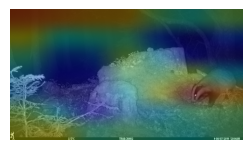

In [15]:
def display_gradcam(img_path, heatmap, alpha = 0.5):
    # Load the original image
    img = keras.preprocessing.image.load_img(img_path)
    img = keras.preprocessing.image.img_to_array(img) 
    
    # Rescale heatmap to a range 0-255.
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap.
    jet = plt.get_cmap("jet")

    # Use RGB values of the colormap.
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap.
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image.
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Display Grad CAM.
    plt.figure(figsize = (3, 3))
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.show()
    
display_gradcam(path_image_test, heatmap)